# Mapa local de obstáculos en CoppeliaSim

## Actividad

**Objetivo de la práctica:** implementar en un simulador un algoritmo capaz de mostrar los obstáculos del medio ambiente tomando como punto de referencia el **centro de rotación del robot**.

La solución desarrollada utiliza:

- **CoppeliaSim** como simulador.
- **Pioneer P3DX** como plataforma móvil.
- **16 sensores ultrasónicos** del modelo.
- **Python** para comunicación, procesamiento y control.
- **ZeroMQ Remote API** para intercambiar información con CoppeliaSim.
- **Pygame** para leer el teclado en Linux y visualizar el mapa local en tiempo real.

El robot se controla con:

| Tecla | Acción |
|---|---|
| `W` | Avanzar |
| `S` | Retroceder |
| `A` | Girar a la izquierda |
| `D` | Girar a la derecha |
| `ESPACIO` | Detener |
| `R` | Limpiar historial, si se utiliza |
| `ESC` | Finalizar |

El propósito de este notebook es que la solución pueda **comprenderse, reproducirse y explicarse**, no solamente ejecutarse.

# 1. Introducción

En robótica móvil, conocer la posición de los obstáculos con respecto al propio robot es indispensable para desarrollar tareas de navegación, evasión de colisiones, planeación de trayectorias y construcción de mapas.

Un robot puede percibir su entorno mediante diferentes sensores, como cámaras, LiDAR, sensores infrarrojos o sensores ultrasónicos. En este trabajo se utilizan los **16 sensores ultrasónicos** incorporados en el modelo Pioneer P3DX de CoppeliaSim.

Cada sensor detecta objetos dentro de su región de percepción y devuelve un punto de detección expresado en el **sistema de coordenadas del propio sensor**. Como los sensores están ubicados en diferentes posiciones y orientaciones alrededor del robot, sus mediciones no pueden dibujarse directamente en un mapa común.

Por esta razón, cada punto detectado debe transformarse al sistema de coordenadas del robot.

El mapa generado es un **mapa local instantáneo**, donde el centro de rotación del Pioneer P3DX se considera siempre como:

$$
(x,y)=(0,0)
$$

Por lo tanto, el robot permanece fijo en el centro de la representación mientras los obstáculos aparecen alrededor de él de acuerdo con las mediciones actuales de los sensores.

Este enfoque permite visualizar en tiempo real **lo que el robot percibe desde su propia perspectiva**.


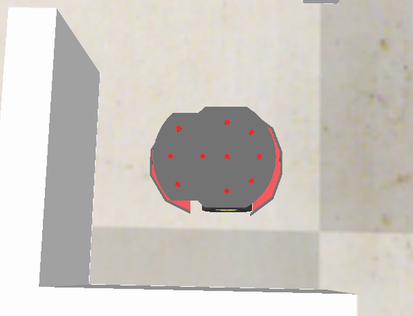

**Figura 1. Pioneer P3DX dentro del entorno de CoppeliaSim.**  

# 2. Metodología

## 2.1 Plataforma robótica Pioneer P3DX

El Pioneer P3DX es un robot móvil con configuración de **tracción diferencial**. El movimiento se genera mediante dos ruedas motrices controladas de manera independiente:

- rueda izquierda: `leftMotor`;
- rueda derecha: `rightMotor`.

En la escena utilizada en CoppeliaSim, el modelo también dispone de 16 sensores ultrasónicos:

```text
ultrasonicSensor[0]
ultrasonicSensor[1]
...
ultrasonicSensor[15]
```

Los sensores se encuentran distribuidos alrededor del robot, por lo que permiten detectar obstáculos en múltiples direcciones.


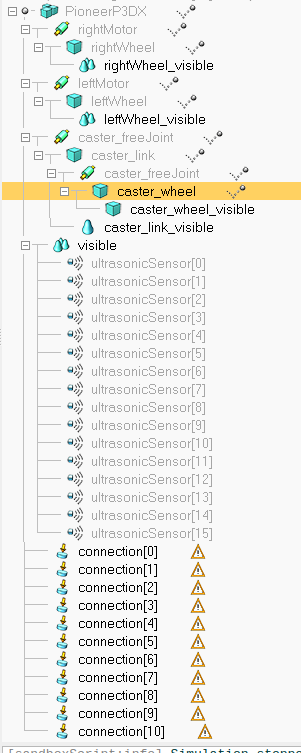

**Figura 2. Jerarquía del Pioneer P3DX en CoppeliaSim.**  

## 2.2 Sistema de locomoción diferencial

En un robot diferencial, las velocidades de las ruedas determinan tanto la velocidad lineal como la velocidad angular del vehículo.

Sean:

- $\omega_L$: velocidad angular de la rueda izquierda;
- $\omega_R$: velocidad angular de la rueda derecha;
- $r$: radio de las ruedas;
- $L$: separación entre las ruedas motrices.

La velocidad lineal del robot puede aproximarse mediante:

$$
v =
\frac{r}{2}
\left(
\omega_R+\omega_L
\right)
$$

La velocidad angular del robot se obtiene mediante:

$$
\omega =
\frac{r}{L}
\left(
\omega_R-\omega_L
\right)
$$

### Movimiento recto

Cuando ambas ruedas giran con la misma velocidad:

$$
\omega_R=\omega_L
$$

entonces:

$$
\omega=0
$$

y el robot se desplaza aproximadamente en línea recta.

### Giro sobre el centro

Cuando las ruedas giran con magnitudes similares pero signos contrarios:

$$
\omega_R=-\omega_L
$$

la velocidad lineal se aproxima a cero:

$$
v\approx0
$$

y el Pioneer gira aproximadamente alrededor del punto medio del eje de sus ruedas.

En el programa:

```text
W -> ( +ω , +ω )
S -> ( -ω , -ω )
A -> ( -ω , +ω )
D -> ( +ω , -ω )
```

Esta relación explica por qué las teclas `A` y `D` permiten realizar giros sobre el centro del robot.

## 2.3 Centro de rotación del Pioneer P3DX

La actividad solicita tomar como referencia el **centro de rotación del robot**.

No se debe asumir automáticamente que el origen geométrico del objeto `/PioneerP3DX` coincide exactamente con ese punto.

En esta implementación, el centro de rotación se estima a partir del punto medio entre las posiciones de los motores de las dos ruedas motrices.

Sean:

$$
\mathbf{p}_L =
\begin{bmatrix}
x_L\\
y_L\\
z_L
\end{bmatrix}
$$

y:

$$
\mathbf{p}_R =
\begin{bmatrix}
x_R\\
y_R\\
z_R
\end{bmatrix}
$$

las posiciones de los motores izquierdo y derecho respecto al frame principal del Pioneer.

El centro de rotación se aproxima mediante:

$$
\mathbf{p}_C =
\frac{\mathbf{p}_L+\mathbf{p}_R}{2}
$$

Por componentes:

$$
x_C=\frac{x_L+x_R}{2}
$$

$$
y_C=\frac{y_L+y_R}{2}
$$

$$
z_C=\frac{z_L+z_R}{2}
$$

Después de calcular este punto, el mapa redefine el centro como:

$$
(x_C,y_C)=(0,0)
$$

Así, todas las detecciones se expresan con respecto al centro real de giro del robot.

-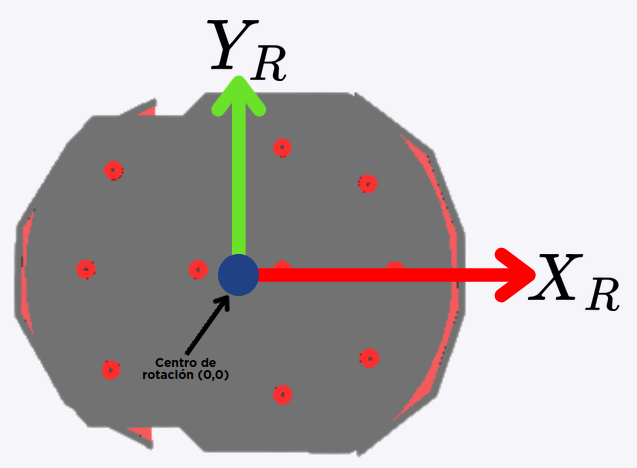

**Figura 3. Sistema de referencia local del Pioneer P3DX.**  

## 2.4 Sensores ultrasónicos

Los sensores ultrasónicos del modelo se representan mediante sensores de proximidad de CoppeliaSim.

Cada sensor $S_i$ puede encontrarse en uno de dos estados:

1. **sin detección**;
2. **con detección**.

Cuando existe detección, CoppeliaSim devuelve un punto tridimensional:

$$
{}^{S_i}\mathbf{p}=
\begin{bmatrix}
x_{S_i}\\
y_{S_i}\\
z_{S_i}
\end{bmatrix}
$$

Estas coordenadas están expresadas respecto al propio sensor $S_i$.

Esto significa que dos sensores pueden detectar obstáculos a distancias similares y, aun así, dichos obstáculos encontrarse en posiciones completamente diferentes respecto al centro del robot.

Por ello, la distancia ultrasónica por sí sola no es suficiente para construir el mapa.


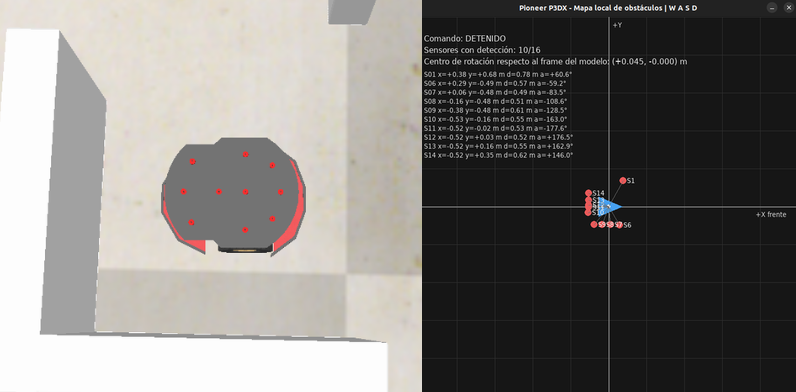

**Figura 4. Distribución o volumen de detección de los sensores ultrasónicos.**  


## 2.5 Sistemas de coordenadas en robótica

Para comprender el algoritmo es importante distinguir tres sistemas de referencia:

### Frame global o del mundo

Es el sistema de coordenadas fijo de CoppeliaSim.

Puede representarse como:

$$
\{W\}
$$

### Frame del robot

Está unido al Pioneer P3DX y se mueve junto con él:

$$
\{R\}
$$

### Frame de cada sensor

Cada ultrasónico tiene su propio sistema:

$$
\{S_0\},\{S_1\},\ldots,\{S_{15}\}
$$

El problema consiste en convertir:

$$
{}^{S_i}\mathbf{p}
\longrightarrow
{}^{R}\mathbf{p}
$$

es decir, transformar un punto medido por un sensor al sistema de referencia común del robot.

## 2.6 Transformaciones homogéneas

La posición y orientación de un sensor respecto al robot pueden representarse mediante una transformación homogénea:

$$
{}^{R}T_{S_i}
=
\begin{bmatrix}
r_{11} & r_{12} & r_{13} & t_x\\
r_{21} & r_{22} & r_{23} & t_y\\
r_{31} & r_{32} & r_{33} & t_z\\
0 & 0 & 0 & 1
\end{bmatrix}
$$

La submatriz:

$$
R=
\begin{bmatrix}
r_{11} & r_{12} & r_{13}\\
r_{21} & r_{22} & r_{23}\\
r_{31} & r_{32} & r_{33}
\end{bmatrix}
$$

representa la **rotación** del sensor, mientras que:

$$
\mathbf{t}=
\begin{bmatrix}
t_x\\
t_y\\
t_z
\end{bmatrix}
$$

representa su **traslación** con respecto al robot.

Para utilizar la matriz homogénea, el punto del sensor se escribe como:

$$
{}^{S_i}\mathbf{P}
=
\begin{bmatrix}
x_{S_i}\\
y_{S_i}\\
z_{S_i}\\
1
\end{bmatrix}
$$

La transformación al frame del robot es:

$$
{}^{R}\mathbf{P}
=
{}^{R}T_{S_i}
{}^{S_i}\mathbf{P}
$$

Por lo tanto:

$$
\begin{bmatrix}
x_R\\
y_R\\
z_R\\
1
\end{bmatrix}
=
{}^{R}T_{S_i}
\begin{bmatrix}
x_{S_i}\\
y_{S_i}\\
z_{S_i}\\
1
\end{bmatrix}
$$

CoppeliaSim proporciona la transformación con:

```python
sim.getObjectMatrix(sensor, robot)
```

y el programa realiza explícitamente la multiplicación matriz-punto.

## 2.7 Traslación al centro de rotación

Después de transformar el punto al frame principal del Pioneer se obtiene:

$$
(x_R,y_R,z_R)
$$

Sin embargo, el objetivo de la actividad es tomar como origen el centro de rotación.

Por ello se aplica:

$$
x_{\text{local}}=x_R-x_C
$$

$$
y_{\text{local}}=y_R-y_C
$$

$$
z_{\text{local}}=z_R-z_C
$$

Para el mapa bidimensional se utilizan únicamente:

$$
(x_{\text{local}},y_{\text{local}})
$$

y el centro del robot se representa siempre en:

$$
(0,0)
$$

## 2.8 Distancia del obstáculo respecto al centro del robot

Una vez obtenidas las coordenadas locales, la distancia plana entre el centro de rotación y el obstáculo se calcula mediante:

$$
d=
\sqrt{
x_{\text{local}}^2+
y_{\text{local}}^2
}
$$

Esta distancia es diferente de la distancia originalmente reportada por el sensor.

- `distance_sensor`: distancia desde el sensor al punto detectado.
- `distance_robot`: distancia desde el centro de rotación al punto detectado.

La segunda es la que interesa para el mapa local solicitado.

## 2.9 Ángulo relativo del obstáculo

La dirección del obstáculo respecto al frente del robot se calcula mediante:

$$
\alpha=
\operatorname{atan2}
\left(
y_{\text{local}},
x_{\text{local}}
\right)
$$

El resultado inicial se encuentra en radianes.

Para convertirlo a grados:

$$
\alpha_{\text{deg}}
=
\alpha
\frac{180^\circ}{\pi}
$$

Cada detección puede describirse entonces como:

$$
\mathbf{o}_i=
\begin{bmatrix}
x_{\text{local}}\\
y_{\text{local}}\\
d\\
\alpha
\end{bmatrix}
$$

Esta representación permite saber:

- dónde está el obstáculo;
- qué tan lejos está;
- en qué dirección se encuentra;
- qué sensor produjo la detección.

## 2.10 Definición del mapa local

El mapa local instantáneo puede definirse como:

$$
\mathcal{M}(t)=
\left\{
(x_1,y_1),
(x_2,y_2),
\ldots,
(x_n,y_n)
\right\}
$$

donde:

$$
0\leq n\leq16
$$

porque cada sensor puede generar como máximo una detección instantánea.

El robot permanece siempre en:

$$
(0,0)
$$

mientras que los puntos de los obstáculos cambian conforme el Pioneer se desplaza o gira.

### Mapa local vs. mapa global

Un **mapa local** está ligado al robot y representa su entorno inmediato.

Un **mapa global** utiliza un sistema fijo y requiere conocer o estimar la pose del robot dentro del mundo.

La implementación actual no intenta construir un mapa persistente del escenario. Su objetivo es mostrar **lo que los sensores están viendo en tiempo real desde el robot**.

Para construir un mapa global acumulativo sería necesario integrar, como mínimo:

- odometría;
- estimación de pose;
- transformación local-global;
- fusión temporal de mediciones.

En sistemas más avanzados podría utilizarse SLAM.

## 2.11 Sincronización con CoppeliaSim

El programa activa:

```python
sim.setStepping(True)
```

Con esta opción, Python controla cuándo avanza la simulación mediante:

```python
sim.step()
```

La secuencia utilizada en cada iteración es:

1. leer el teclado;
2. actualizar velocidades de las ruedas;
3. avanzar un paso de CoppeliaSim;
4. leer los 16 sensores;
5. transformar las detecciones;
6. actualizar el mapa local.

Esto mantiene sincronizados:

- control;
- movimiento;
- percepción;
- visualización.

## 2.12 Lectura de teclado en Linux

Para controlar el Pioneer se utiliza **Pygame**.

La decisión es importante en Linux porque algunas librerías de teclado global pueden depender de:

- permisos del sistema;
- dispositivos `/dev/input`;
- X11;
- Wayland;
- configuración de seguridad de la sesión.

Pygame evita interceptar globalmente el teclado. En lugar de ello, crea una ventana propia y captura las teclas cuando dicha ventana tiene el foco.

Además, se utiliza la misma ventana para visualizar el mapa local.

El control implementa un comportamiento tipo **dead-man switch**:

> si no se mantiene presionada una tecla de movimiento, las velocidades de las ruedas regresan a cero.

Esto evita que el robot continúe avanzando después de soltar el control.

## 2.13 Conversión de coordenadas métricas a píxeles

Las detecciones se encuentran originalmente en metros.

Pygame dibuja utilizando píxeles, por lo que se realiza una segunda transformación exclusivamente gráfica.

Si:

- $W$ es el ancho de la ventana;
- $R_m$ es el alcance mostrado en metros;

entonces la escala es:

$$
s=
\frac{W/2}{R_m}
$$

en píxeles por metro.

La transformación horizontal es:

$$
p_x=
\frac{W}{2}
+
x_{\text{local}}s
$$

Para el eje vertical debe considerarse que en Pygame el eje $Y$ crece hacia abajo.

Por ello:

$$
p_y=
\frac{W}{2}
-
y_{\text{local}}s
$$

El signo negativo permite que el mapa gráfico conserve la orientación cartesiana habitual, donde $+Y$ apunta hacia arriba.

# 3 Implementación

## 3.1 Código fuente utilizado

El siguiente código corresponde a la implementación completa utilizada para el experimento.

In [5]:
import math
import time
from collections import deque
import pygame
from coppeliasim_zmqremoteapi_client import RemoteAPIClient


class PioneerP3DXLocalMapper:
    """Controlar el robot y generar un mapa local con sus sensores ultrasónicos."""

    def __init__(
        self,
        linear_wheel_speed=2.0,
        turn_wheel_speed=1.5,
        map_range=5.0,
        window_size=760,
        history_length=0,
    ):
        """
        Inicializar comunicación, parámetros de control y visualización.

        Parameters
        ----------
        linear_wheel_speed : float
            Velocidad angular de cada rueda para avance/retroceso [rad/s].
        turn_wheel_speed : float
            Magnitud de velocidad angular para giro sobre el centro [rad/s].
        map_range : float
            Alcance mostrado a cada lado del origen del mapa [m].
        window_size : int
            Tamaño en píxeles de la ventana cuadrada.
        history_length : int
            Cantidad máxima de puntos históricos a conservar. Si es 0,
            solamente se muestran las detecciones instantáneas.
        """
        self.client = RemoteAPIClient()
        self.sim = self.client.require("sim")

        # Stepping=True hace que Python controle cuándo avanza un paso la simulación.
        # Esto sincroniza lectura de sensores, movimiento y visualización.
        self.sim.setStepping(True)

        # Handles del Pioneer P3DX y sus actuadores.
        self.robot = self.sim.getObject("/PioneerP3DX")
        self.left_motor = self.sim.getObject("/PioneerP3DX/leftMotor")
        self.right_motor = self.sim.getObject("/PioneerP3DX/rightMotor")

        # La jerarquía proporcionada muestra 16 sensores, numerados 0...15.
        self.sensors = [
            self.sim.getObject(f"/PioneerP3DX/ultrasonicSensor[{i}]")
            for i in range(16)
        ]

        self.linear_wheel_speed = float(linear_wheel_speed)
        self.turn_wheel_speed = float(turn_wheel_speed)
        self.map_range = float(map_range)
        self.window_size = int(window_size)

        # Guardar puntos anteriores es opcional. Para un mapa local estrictamente
        # instantáneo, usar history_length=0.
        self.history = deque(maxlen=history_length if history_length > 0 else 1)
        self.use_history = history_length > 0

        # El centro instantáneo de rotación de un robot diferencial que gira
        # sobre sí mismo se encuentra en el punto medio del eje entre ruedas.
        # Se calcula este punto respecto al frame principal del Pioneer.
        left_pos = self.sim.getObjectPosition(self.left_motor, self.robot)
        right_pos = self.sim.getObjectPosition(self.right_motor, self.robot)

        self.rotation_center = [
            (left_pos[0] + right_pos[0]) / 2.0,
            (left_pos[1] + right_pos[1]) / 2.0,
            (left_pos[2] + right_pos[2]) / 2.0,
        ]

        # Inicialización de la ventana gráfica y del teclado.
        pygame.init()
        pygame.display.set_caption(
            "Pioneer P3DX - Mapa local de obstáculos | W A S D"
        )
        self.screen = pygame.display.set_mode(
            (self.window_size, self.window_size)
        )
        self.font = pygame.font.SysFont("DejaVu Sans", 17)
        self.small_font = pygame.font.SysFont("DejaVu Sans", 14)
        self.clock = pygame.time.Clock()

        self.running = True
        self.simulation_started = False
        self.current_command = "DETENIDO"

    @staticmethod
    def transform_point(matrix, point):
        """
        Transformar un punto 3D usando la matriz 3x4 de CoppeliaSim.

        Parameters
        ----------
        matrix : list[float]
            Matriz de transformación 3x4, almacenada en 12 elementos.
        point : list[float]
            Punto [x, y, z] expresado en el frame origen.

        Returns
        -------
        tuple[float, float, float]
            Punto expresado en el frame destino.
        """
        x = (
            matrix[0] * point[0]
            + matrix[1] * point[1]
            + matrix[2] * point[2]
            + matrix[3]
        )
        y = (
            matrix[4] * point[0]
            + matrix[5] * point[1]
            + matrix[6] * point[2]
            + matrix[7]
        )
        z = (
            matrix[8] * point[0]
            + matrix[9] * point[1]
            + matrix[10] * point[2]
            + matrix[11]
        )
        return x, y, z

    def start_simulation(self):
        """Iniciar CoppeliaSim y estabilizar los sensores durante algunos pasos."""
        self.sim.startSimulation()
        self.simulation_started = True

        # Dar varios pasos antes de la primera lectura.
        for _ in range(5):
            self.sim.step()

    def set_wheel_velocities(self, left, right):
        """
        Aplicar velocidades angulares a las ruedas izquierda y derecha.

        Parameters
        ----------
        left : float
            Velocidad de la rueda izquierda [rad/s].
        right : float
            Velocidad de la rueda derecha [rad/s].
        """
        self.sim.setJointTargetVelocity(self.left_motor, float(left))
        self.sim.setJointTargetVelocity(self.right_motor, float(right))

    def stop_robot(self):
        """Detener las dos ruedas del Pioneer P3DX."""
        self.set_wheel_velocities(0.0, 0.0)
        self.current_command = "DETENIDO"

    def process_keyboard(self):
        """
        Leer eventos y estado del teclado desde Pygame.

        En Linux esta estrategia funciona mientras la ventana tenga el foco
        y no requiere interceptar globalmente las teclas del sistema operativo.
        """
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                self.running = False

            elif event.type == pygame.KEYDOWN:
                if event.key == pygame.K_ESCAPE:
                    self.running = False

                elif event.key == pygame.K_SPACE:
                    self.stop_robot()

                elif event.key == pygame.K_r:
                    self.history.clear()

        keys = pygame.key.get_pressed()

        # Prioridad simple: avance/retroceso y después giro.
        if keys[pygame.K_w]:
            self.set_wheel_velocities(
                self.linear_wheel_speed,
                self.linear_wheel_speed,
            )
            self.current_command = "AVANZAR"

        elif keys[pygame.K_s]:
            self.set_wheel_velocities(
                -self.linear_wheel_speed,
                -self.linear_wheel_speed,
            )
            self.current_command = "RETROCEDER"

        elif keys[pygame.K_a]:
            # Velocidades opuestas: giro aproximadamente sobre el centro del eje.
            self.set_wheel_velocities(
                -self.turn_wheel_speed,
                self.turn_wheel_speed,
            )
            self.current_command = "GIRO IZQUIERDA"

        elif keys[pygame.K_d]:
            self.set_wheel_velocities(
                self.turn_wheel_speed,
                -self.turn_wheel_speed,
            )
            self.current_command = "GIRO DERECHA"

        else:
            # Control tipo "dead-man": al soltar W/A/S/D el robot se detiene.
            self.stop_robot()

    def read_ultrasonic_sensors(self):
        """
        Leer los 16 sensores y transformar cada detección al centro de rotación.

        Returns
        -------
        list[dict]
            Detecciones instantáneas. Cada elemento contiene:
            sensor, x, y, z, distance_robot, angle_deg y distance_sensor.
        """
        detections = []

        for sensor_index, sensor in enumerate(self.sensors):
            # CoppeliaSim devuelve el punto detectado en el frame DEL SENSOR.
            result, sensor_distance, detected_point, detected_object, normal = (
                self.sim.readProximitySensor(sensor)
            )

            if result <= 0:
                continue

            # Matriz que transforma coordenadas del sensor al frame principal
            # del Pioneer P3DX.
            sensor_to_robot = self.sim.getObjectMatrix(sensor, self.robot)

            x_root, y_root, z_root = self.transform_point(
                sensor_to_robot,
                detected_point,
            )

            # Trasladar el origen desde el frame principal del modelo hasta
            # el centro real de rotación estimado como el punto medio entre ruedas.
            x_local = x_root - self.rotation_center[0]
            y_local = y_root - self.rotation_center[1]
            z_local = z_root - self.rotation_center[2]

            # Distancia plana desde el centro de rotación hasta el punto detectado.
            distance_robot = math.hypot(x_local, y_local)

            # Dirección del obstáculo respecto al eje X local del Pioneer.
            angle_deg = math.degrees(math.atan2(y_local, x_local))

            detections.append(
                {
                    "sensor": sensor_index,
                    "x": x_local,
                    "y": y_local,
                    "z": z_local,
                    "distance_sensor": sensor_distance,
                    "distance_robot": distance_robot,
                    "angle_deg": angle_deg,
                    "object_handle": detected_object,
                }
            )

        if self.use_history:
            for detection in detections:
                self.history.append((detection["x"], detection["y"]))

        return detections

    def world_to_screen(self, x, y):
        """
        Convertir metros del mapa local a píxeles de la ventana.

        El origen gráfico se coloca en el centro de la ventana. El eje Y
        de Pygame crece hacia abajo, por eso se invierte el signo de y.
        """
        half = self.window_size / 2.0
        pixels_per_meter = half / self.map_range

        px = int(half + x * pixels_per_meter)
        py = int(half - y * pixels_per_meter)
        return px, py

    def draw_grid(self):
        """Dibujar cuadrícula métrica y ejes X-Y del mapa local."""
        self.screen.fill((22, 22, 22))

        half = self.window_size // 2
        ppm = half / self.map_range

        # Cuadrícula cada 1 metro.
        max_tick = int(self.map_range)
        for meter in range(-max_tick, max_tick + 1):
            px = int(half + meter * ppm)
            py = int(half - meter * ppm)

            pygame.draw.line(
                self.screen, (48, 48, 48),
                (px, 0), (px, self.window_size), 1
            )
            pygame.draw.line(
                self.screen, (48, 48, 48),
                (0, py), (self.window_size, py), 1
            )

        # Ejes principales.
        pygame.draw.line(
            self.screen, (130, 130, 130),
            (0, half), (self.window_size, half), 2
        )
        pygame.draw.line(
            self.screen, (130, 130, 130),
            (half, 0), (half, self.window_size), 2
        )

        self.screen.blit(
            self.small_font.render("+X frente", True, (220, 220, 220)),
            (self.window_size - 85, half + 8),
        )
        self.screen.blit(
            self.small_font.render("+Y", True, (220, 220, 220)),
            (half + 8, 8),
        )

    def draw_robot(self):
        """
        Dibujar el Pioneer fijo en (0,0).

        El triángulo apunta hacia +X para indicar el frente del robot.
        """
        cx = self.window_size // 2
        cy = self.window_size // 2

        points = [
            (cx + 28, cy),
            (cx - 20, cy - 20),
            (cx - 20, cy + 20),
        ]
        pygame.draw.polygon(self.screen, (70, 160, 240), points)
        pygame.draw.circle(self.screen, (245, 245, 245), (cx, cy), 4)

    def draw_detections(self, detections):
        """Dibujar detecciones instantáneas y etiquetas de sensor."""
        if self.use_history:
            for x, y in self.history:
                px, py = self.world_to_screen(x, y)
                pygame.draw.circle(self.screen, (90, 90, 90), (px, py), 2)

        for detection in detections:
            px, py = self.world_to_screen(detection["x"], detection["y"])

            # Punto detectado.
            pygame.draw.circle(self.screen, (235, 90, 90), (px, py), 7)

            # Línea radial desde el centro de rotación.
            center = (self.window_size // 2, self.window_size // 2)
            pygame.draw.line(
                self.screen, (110, 110, 110), center, (px, py), 1
            )

            label = self.small_font.render(
                f"S{detection['sensor']}",
                True,
                (245, 245, 245),
            )
            self.screen.blit(label, (px + 8, py - 8))

    def draw_status(self, detections):
        """Mostrar estado del robot y resumen de detecciones."""
        lines = [
            "",
            f"Comando: {self.current_command}",
            f"Sensores con detección: {len(detections)}/16",
            (
                "Centro de rotación respecto al frame del modelo: "
                f"({self.rotation_center[0]:+.3f}, "
                f"{self.rotation_center[1]:+.3f}) m"
            ),
        ]

        y = 10
        for line in lines:
            text = self.font.render(line, True, (235, 235, 235))
            self.screen.blit(text, (10, y))
            y += 23

        # Tabla compacta de sensores activos.
        y += 5
        for detection in detections[:16]:
            text = self.small_font.render(
                (
                    f"S{detection['sensor']:02d} "
                    f"x={detection['x']:+.2f} "
                    f"y={detection['y']:+.2f} m "
                    f"d={detection['distance_robot']:.2f} m "
                    f"a={detection['angle_deg']:+.1f}°"
                ),
                True,
                (220, 220, 220),
            )
            self.screen.blit(text, (10, y))
            y += 18

    def draw(self, detections):
        """Actualizar completamente la visualización del mapa local."""
        self.draw_grid()
        self.draw_robot()
        self.draw_detections(detections)
        self.draw_status(detections)
        pygame.display.flip()

    def run(self):
        """
        Ejecutar el ciclo principal de control, sensado y visualización.

        Secuencia por iteración:
            1. Leer teclado.
            2. Aplicar velocidades.
            3. Avanzar un paso de simulación.
            4. Leer los 16 sensores.
            5. Transformar detecciones al centro de rotación.
            6. Dibujar el mapa local.
        """
        try:
            self.start_simulation()

            while self.running:
                self.process_keyboard()

                # Avanzar exactamente un paso de CoppeliaSim.
                self.sim.step()

                detections = self.read_ultrasonic_sensors()
                self.draw(detections)

                # Limitar la interfaz para no consumir CPU innecesariamente.
                self.clock.tick(60)

        finally:
            self.stop_robot()

            if self.simulation_started:
                # Aplicar la orden de paro antes de detener la simulación.
                try:
                    self.sim.step()
                    self.sim.stopSimulation()
                except Exception:
                    pass

            pygame.quit()


if __name__ == "__main__":
    mapper = PioneerP3DXLocalMapper(
        linear_wheel_speed=2.0,
        turn_wheel_speed=1.5,
        map_range=5.0,
        window_size=760,
        history_length=0,   # 0 = mapa local instantáneo.
    )
    mapper.run()

# 4. Resultados
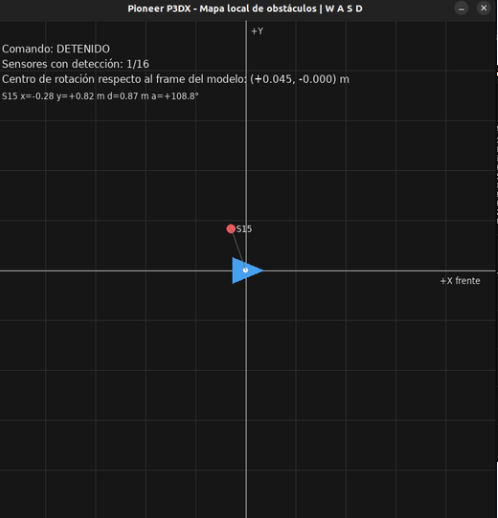
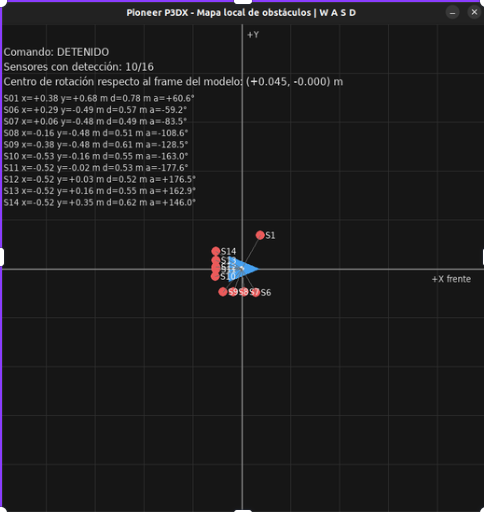
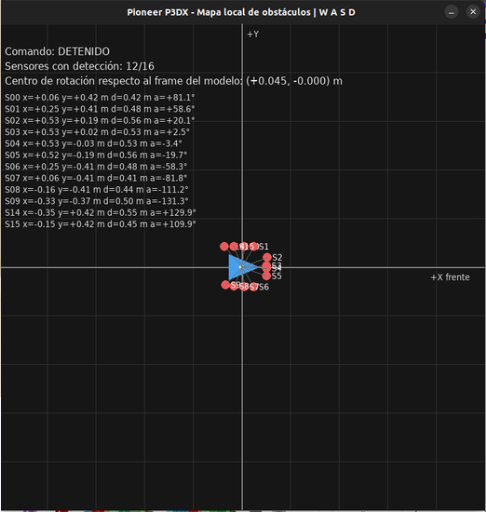


## 4.1 Configuración inicial del escenario

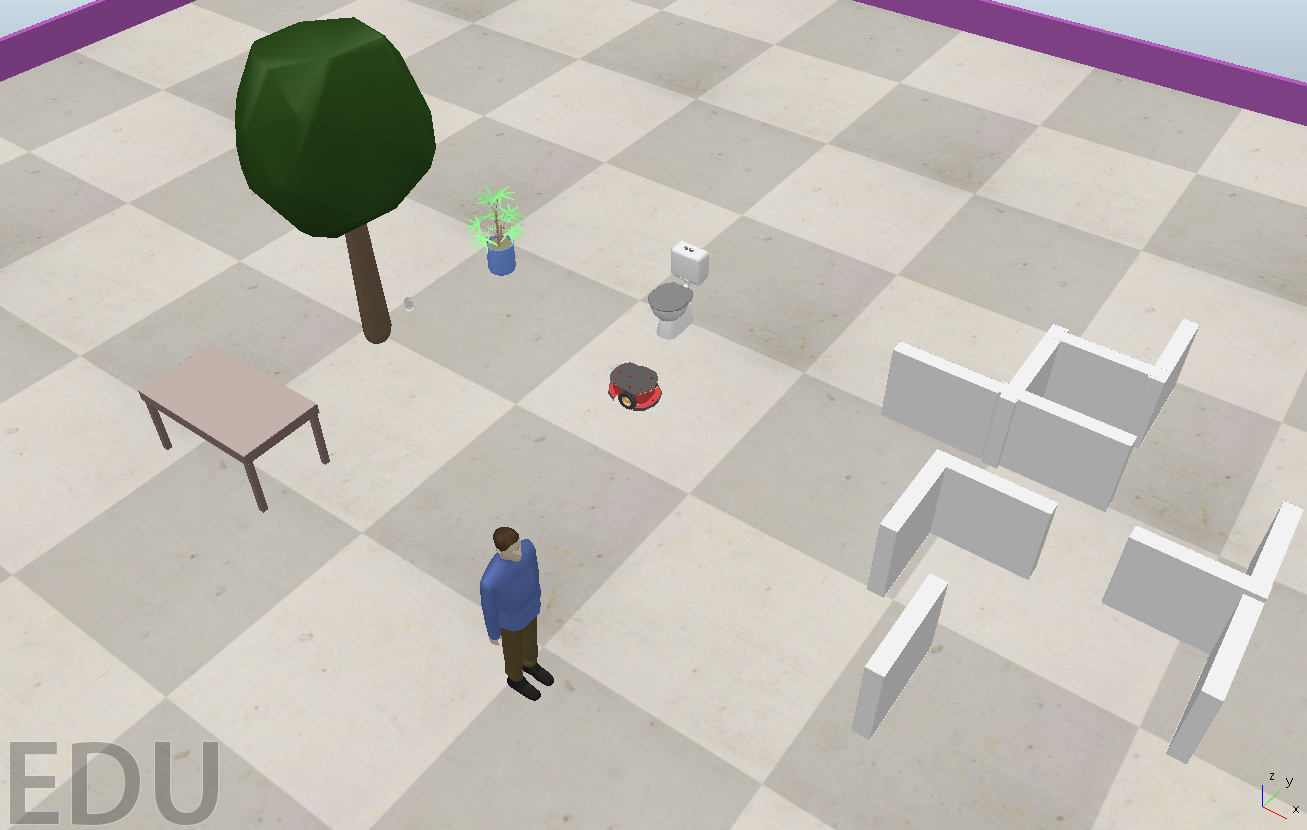

**Figura 5. Escenario inicial utilizado para las pruebas.**  

**Comentario de resultados:**  
En esta configuración se colocaron obstáculos en diferentes direcciones con respecto al robot para provocar detecciones simultáneas en más de un sensor. Esto permite evaluar si las mediciones provenientes de distintos frames pueden representarse correctamente dentro de un mismo mapa local.

# 5. Conclusiones

Se implementó en CoppeliaSim un algoritmo capaz de representar en tiempo real los obstáculos detectados alrededor de un robot Pioneer P3DX, utilizando como referencia su centro de rotación.

La solución utiliza los 16 sensores ultrasónicos del modelo y transforma cada punto detectado desde el sistema de coordenadas particular de su sensor hacia un sistema de referencia común asociado al robot.

El centro de rotación se estimó a partir del punto medio entre las dos ruedas motrices y posteriormente se estableció como el origen $(0,0)$ del mapa local.

La visualización desarrollada permite observar en tiempo real cómo cambian las posiciones relativas de los obstáculos mientras el Pioneer es controlado mediante las teclas W, A, S y D.

El trabajo permite comprender de forma práctica la relación entre percepción, sistemas de referencia, transformaciones homogéneas, cinemática diferencial y mapas locales en robótica móvil.

Finalmente, la solución constituye una base para implementar posteriormente algoritmos de evasión de obstáculos, planeación de trayectorias, mapas globales, odometría y SLAM.